<a href="https://colab.research.google.com/github/A-Chakraborty-3/-Brain-Tumor-Segmentation-using-3D-AGSE-U-Net/blob/main/BrainTumorSegmentation_3DUNet_AGSE_(1)_(2)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Brain Tumor Segmentation — 3D UNet-AGSE
### BRaTS 2021 Challenge · Adam Optimizer · Google Colab Free Tier

---
**Architecture:** 3D UNet + Attention Gates + Squeeze-and-Excitation (AGSE)  
**Dataset:** BRaTS 2021 (Google Drive)  
**Patients:** 300 sampled · Train/Val/Test split  
**Targets:** WT (Whole Tumor) · TC (Tumor Core) · ET (Enhancing Tumor)  

⚠️ **Colab Free-Tier Optimizations:** Patch-based 96³ training, FP16 mixed precision, gradient accumulation, auto checkpoint/resume.

In [ ]:
# Cell 1 — Install Dependencies
import subprocess, sys
for pkg in ['nibabel', 'monai', 'einops', 'scikit-learn', 'tqdm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages installed.')

All packages installed.


## Cell 2 — Imports & Reproducibility

In [ ]:
import os, gc, random, warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {total_mem:.1f} GB')

Device: cuda
GPU: NVIDIA L4
VRAM: 23.7 GB


## Cell 3 — Mount Google Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ======================================================
#  EDIT THIS PATH to match your Google Drive layout
#  Expected structure:
#    MyDrive/BRaTS2021/
#      BraTS2021_00000/
#        BraTS2021_00000_flair.nii.gz
#        BraTS2021_00000_t1.nii.gz
#        BraTS2021_00000_t1ce.nii.gz
#        BraTS2021_00000_t2.nii.gz
#        BraTS2021_00000_seg.nii.gz
# ======================================================
DRIVE_ROOT     = Path("/content/drive/MyDrive")
DATASET_DIR    = DRIVE_ROOT / "BraTS2021_Dataset"
CHECKPOINT_DIR = DRIVE_ROOT / "AGSE_UNet3D_Models"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if DATASET_DIR.exists():
    patient_dirs = sorted([d for d in DATASET_DIR.iterdir() if d.is_dir()])
    print(f'Dataset found: {len(patient_dirs)} patient folders')
    print(f'Example: {patient_dirs[0].name}')
else:
    print(f'ERROR: Dataset not found at {DATASET_DIR}')
    print('Please update DATASET_DIR above.')

Mounted at /content/drive
Dataset found: 1251 patient folders
Example: BraTS2021_00000


## Cell 4 — Hyperparameters

In [ ]:
CFG = dict(
    num_patients       = 300,
    val_split          = 0.15,
    test_split         = 0.05,
    modalities         = ['flair', 't1ce', 't2', 't1'],
    num_classes        = 4,
    patch_size         = (96, 96, 96),
    patches_per_volume = 2,
    base_filters       = 16,
    se_reduction       = 4,
    dropout            = 0.1,
    epochs             = 75,
    batch_size         = 1,
    accum_steps        = 4,
    lr                 = 1e-4,
    weight_decay       = 1e-5,
    dice_weight        = 0.6,
    focal_weight       = 0.4,
    focal_gamma        = 2.0,
    save_every         = 5,
    early_stop_patience = 10,
    mixed_precision    = True,
)
print('Configuration:')
for k, v in CFG.items():
    print(f'  {k:<25} {v}')

Configuration:
  num_patients              300
  val_split                 0.15
  test_split                0.05
  modalities                ['flair', 't1ce', 't2', 't1']
  num_classes               4
  patch_size                (96, 96, 96)
  patches_per_volume        2
  base_filters              16
  se_reduction              4
  dropout                   0.1
  epochs                    75
  batch_size                1
  accum_steps               4
  lr                        0.0001
  weight_decay              1e-05
  dice_weight               0.6
  focal_weight              0.4
  focal_gamma               2.0
  save_every                5
  early_stop_patience       10
  mixed_precision           True


## Cell 5 — Patient Sampling & Train/Val/Test Split

In [ ]:
def get_patient_dirs(dataset_dir, num_patients, seed=SEED):
    all_dirs = sorted([d for d in dataset_dir.iterdir() if d.is_dir()])
    valid = []
    required = ['flair', 't1', 't1ce', 't2', 'seg']
    for d in all_dirs:
        name = d.name
        if all((d / f'{name}_{s}.nii.gz').exists() for s in required):
            valid.append(d)
    print(f'Valid patients in dataset: {len(valid)}')
    rng = random.Random(seed)
    return sorted(rng.sample(valid, min(num_patients, len(valid))))

all_patients = get_patient_dirs(DATASET_DIR, CFG['num_patients'])
print(f'Sampled: {len(all_patients)} patients')

test_size = CFG['test_split']
val_size  = CFG['val_split'] / (1 - test_size)
train_val, test_pts  = train_test_split(all_patients, test_size=test_size, random_state=SEED)
train_pts, val_pts   = train_test_split(train_val,    test_size=val_size,  random_state=SEED)
print(f'Train: {len(train_pts)}  Val: {len(val_pts)}  Test: {len(test_pts)}')

Valid patients in dataset: 1251
Sampled: 300 patients
Train: 240  Val: 45  Test: 15


## Cell 6 — Dataset & DataLoader

In [ ]:
class BRaTS2021Dataset(Dataset):
    MODALITIES = ['flair', 't1ce', 't2', 't1']

    def __init__(self, patient_dirs, patch_size=(96,96,96), patches_per_volume=2, augment=False):
        self.patients = patient_dirs
        self.patch_size = patch_size
        self.patches_per_volume = patches_per_volume
        self.augment = augment
        self.index = [(p, i) for p in range(len(patient_dirs)) for i in range(patches_per_volume)]

    @staticmethod
    def _load_vol(path):
        return nib.load(str(path)).get_fdata(dtype=np.float32)

    @staticmethod
    def _znorm(vol):
        mask = vol > 0
        if mask.sum() == 0:
            return vol
        mu, sigma = vol[mask].mean(), vol[mask].std()
        vol = (vol - mu) / (sigma + 1e-8)
        vol *= mask
        return vol

    @staticmethod
    def _random_crop(vol, seg, patch_size):
        D, H, W = vol.shape[1:]
        pd, ph, pw = patch_size
        if np.random.rand() < 0.5 and seg.max() > 0:
            coords = np.argwhere(seg > 0)
            c = coords[np.random.randint(len(coords))]
            d0 = int(np.clip(c[0] - pd // 2, 0, max(D - pd, 0)))
            h0 = int(np.clip(c[1] - ph // 2, 0, max(H - ph, 0)))
            w0 = int(np.clip(c[2] - pw // 2, 0, max(W - pw, 0)))
        else:
            d0 = random.randint(0, max(D - pd, 0))
            h0 = random.randint(0, max(H - ph, 0))
            w0 = random.randint(0, max(W - pw, 0))
        return vol[:, d0:d0+pd, h0:h0+ph, w0:w0+pw], seg[d0:d0+pd, h0:h0+ph, w0:w0+pw]

    @staticmethod
    def _augment(vol, seg):
        for ax in range(1, 4):
            if random.random() < 0.5:
                vol = np.flip(vol, axis=ax).copy()
                seg = np.flip(seg, axis=ax - 1).copy()
        scale = np.random.uniform(0.9, 1.1)
        shift = np.random.uniform(-0.05, 0.05)
        vol = vol * scale + shift
        return vol, seg

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        pat_idx, _ = self.index[idx]
        d = self.patients[pat_idx]
        name = d.name
        vols = [self._znorm(self._load_vol(d / f'{name}_{m}.nii.gz')) for m in self.MODALITIES]
        vol = np.stack(vols, axis=0)
        seg = self._load_vol(d / f'{name}_seg.nii.gz').astype(np.int64)
        seg[seg == 4] = 3
        # Pad if volume smaller than patch
        D, H, W = vol.shape[1:]
        pd, ph, pw = self.patch_size
        pad = [(0, max(0, pd - D)), (0, max(0, ph - H)), (0, max(0, pw - W))]
        if any(p[1] > 0 for p in pad):
            vol = np.pad(vol, [(0, 0)] + pad)
            seg = np.pad(seg, pad)
        vol, seg = self._random_crop(vol, seg, self.patch_size)
        if self.augment:
            vol, seg = self._augment(vol, seg)
        return torch.tensor(vol, dtype=torch.float32), torch.tensor(seg, dtype=torch.long)


train_ds = BRaTS2021Dataset(train_pts, CFG['patch_size'], CFG['patches_per_volume'], augment=True)
val_ds   = BRaTS2021Dataset(val_pts,   CFG['patch_size'], 1, augment=False)
test_ds  = BRaTS2021Dataset(test_pts,  CFG['patch_size'], 1, augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1,                 shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,                 shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 480  Val: 45  Test: 15


## Cell 7 — 3D UNet-AGSE Architecture

Each block = Double Conv3D + **SE (Squeeze-Excitation)** + Residual shortcut.  
Each skip connection = **Attention Gate** that learns where to focus.

In [ ]:
# ── Building blocks ────────────────────────────────────────────────────────

class ConvBnReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class SEBlock3D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):
        B, C = x.shape[:2]
        s = x.view(B, C, -1).mean(dim=-1)
        w = self.fc(s).view(B, C, 1, 1, 1)
        return x * w


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, se_reduction=4, dropout=0.1):
        super().__init__()
        self.conv1 = ConvBnReLU(in_ch, out_ch)
        self.conv2 = nn.Sequential(
            nn.Conv3d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm3d(out_ch),
        )
        self.se = SEBlock3D(out_ch, se_reduction)
        self.drop = nn.Dropout3d(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = (
            nn.Sequential(nn.Conv3d(in_ch, out_ch, 1, bias=False), nn.BatchNorm3d(out_ch))
            if in_ch != out_ch else nn.Identity()
        )
    def forward(self, x):
        r = self.shortcut(x)
        o = self.conv1(x)
        o = self.conv2(o)
        o = self.se(o)
        o = self.drop(o)
        return self.relu(o + r)


class AttentionGate3D(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv3d(F_g, F_int, 1), nn.BatchNorm3d(F_int))
        self.W_x = nn.Sequential(nn.Conv3d(F_l, F_int, 1), nn.BatchNorm3d(F_int))
        self.psi = nn.Sequential(nn.Conv3d(F_int, 1, 1), nn.BatchNorm3d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape != x1.shape:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='trilinear', align_corners=False)
        return x * self.psi(self.relu(g1 + x1))


# ── Full 3D UNet-AGSE ───────────────────────────────────────────────────────

class UNet3D_AGSE(nn.Module):
    def __init__(self, in_ch=4, num_classes=4, base_filters=16, se_r=4, dropout=0.1):
        super().__init__()
        F = base_filters
        # Encoder
        self.enc1 = ResidualBlock(in_ch, F,    se_r, dropout)
        self.enc2 = ResidualBlock(F,     F*2,  se_r, dropout)
        self.enc3 = ResidualBlock(F*2,   F*4,  se_r, dropout)
        self.enc4 = ResidualBlock(F*4,   F*8,  se_r, dropout)
        # Downsampling
        self.down1 = nn.Conv3d(F,    F,    2, stride=2, bias=False)
        self.down2 = nn.Conv3d(F*2,  F*2,  2, stride=2, bias=False)
        self.down3 = nn.Conv3d(F*4,  F*4,  2, stride=2, bias=False)
        self.down4 = nn.Conv3d(F*8,  F*8,  2, stride=2, bias=False)
        # Bottleneck
        self.bottleneck = ResidualBlock(F*8, F*16, se_r, dropout)
        # Attention gates - CORRECTED F_g parameter
        self.ag4 = AttentionGate3D(F*8,  F*8,  F*4)
        self.ag3 = AttentionGate3D(F*4,  F*4,  F*2)
        self.ag2 = AttentionGate3D(F*2,  F*2,  F)
        self.ag1 = AttentionGate3D(F,    F,    F//2)
        # Decoder
        self.up4  = nn.ConvTranspose3d(F*16, F*8, 2, stride=2)
        self.dec4 = ResidualBlock(F*16, F*8,  se_r, dropout)
        self.up3  = nn.ConvTranspose3d(F*8,  F*4, 2, stride=2)
        self.dec3 = ResidualBlock(F*8,  F*4,  se_r, dropout)
        self.up2  = nn.ConvTranspose3d(F*4,  F*2, 2, stride=2)
        self.dec2 = ResidualBlock(F*4,  F*2,  se_r, dropout)
        self.up1  = nn.ConvTranspose3d(F*2,  F,   2, stride=2)
        self.dec1 = ResidualBlock(F*2,  F,    se_r, dropout)
        # Output
        self.out  = nn.Conv3d(F, num_classes, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        e3 = self.enc3(self.down2(e2))
        e4 = self.enc4(self.down3(e3))
        b  = self.bottleneck(self.down4(e4))
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, self.ag4(d4, e4)], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, self.ag3(d3, e3)], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, self.ag2(d2, e2)], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, self.ag1(d1, e1)], dim=1))
        return self.out(d1)


model = UNet3D_AGSE(
    in_ch=len(CFG['modalities']), num_classes=CFG['num_classes'],
    base_filters=CFG['base_filters'], se_r=CFG['se_reduction'], dropout=CFG['dropout']
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model ready — {n_params:,} parameters')
with torch.no_grad(), autocast():
    dummy = torch.randn(1, 4, *CFG['patch_size']).to(DEVICE)
    out   = model(dummy)
    print(f'Input {tuple(dummy.shape)} -> Output {tuple(out.shape)}')
del dummy, out
torch.cuda.empty_cache()

Model ready — 5,987,528 parameters
Input (1, 4, 96, 96, 96) -> Output (1, 4, 96, 96, 96)


## Cell 8 — Loss Functions (Dice + Focal)

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes=4, smooth=1e-5):
        super().__init__()
        self.C = num_classes
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        B, C, D, H, W = logits.shape
        oh = F.one_hot(targets.clamp(0, C-1), C).permute(0,4,1,2,3).float()
        losses = []
        for c in range(1, C):
            p, g = probs[:,c], oh[:,c]
            inter = (p*g).sum()
            losses.append(1 - (2*inter + self.smooth) / (p.sum()+g.sum()+self.smooth))
        return torch.stack(losses).mean()


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_w=0.6, focal_w=0.4, gamma=2.0, num_classes=4):
        super().__init__()
        self.dice_w = dice_w; self.focal_w = focal_w
        self.dice = DiceLoss(num_classes)
        self.focal = FocalLoss(gamma)
    def forward(self, logits, targets):
        d = self.dice(logits, targets)
        f = self.focal(logits, targets)
        return self.dice_w*d + self.focal_w*f, d.item(), f.item()


criterion = CombinedLoss(
    dice_w=CFG['dice_weight'], focal_w=CFG['focal_weight'],
    gamma=CFG['focal_gamma'], num_classes=CFG['num_classes']
).to(DEVICE)
print('Combined loss ready.')

Combined loss ready.


## Cell 9 — Optimizer, Scheduler & Metrics

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'],
    betas=(0.9, 0.999), eps=1e-8
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=CFG['lr']*1e-3
)
scaler = GradScaler(enabled=CFG['mixed_precision'] and DEVICE.type == 'cuda')


def brats_dice(logits, targets):
    pred = logits.argmax(dim=1)
    smooth = 1e-5
    regions = {
        'Dice_WT': (pred > 0,              targets > 0),
        'Dice_TC': ((pred==1)|(pred==3),   (targets==1)|(targets==3)),
        'Dice_ET': (pred == 3,             targets == 3),
    }
    out = {}
    for k, (p, g) in regions.items():
        p, g = p.float(), g.float()
        inter = (p*g).sum()
        out[k] = ((2*inter + smooth) / (p.sum()+g.sum()+smooth)).item()
    return out


print('Adam optimizer + CosineAnnealing LR scheduler ready.')

Adam optimizer + CosineAnnealing LR scheduler ready.


## Cell 10 — Checkpoint Utilities (Auto-resume)

In [ ]:
CKPT_BEST   = CHECKPOINT_DIR / 'best_model.pth'
CKPT_LATEST = CHECKPOINT_DIR / 'latest_model.pth'

def save_ckpt(epoch, model, optimizer, scheduler, scaler, history, best, path):
    torch.save({
        'epoch': epoch, 'model': model.state_dict(),
        'optim': optimizer.state_dict(), 'sched': scheduler.state_dict(),
        'scaler': scaler.state_dict(), 'history': history, 'best': best
    }, path)


def load_ckpt(path, model, optimizer=None, scheduler=None, scaler=None):
    s = torch.load(path, map_location=DEVICE)
    model.load_state_dict(s['model'])
    if optimizer: optimizer.load_state_dict(s['optim'])
    if scheduler: scheduler.load_state_dict(s['sched'])
    if scaler:    scaler.load_state_dict(s['scaler'])
    return s['epoch'], s.get('best', 0.0), s.get('history', {})


start_epoch  = 0
best_dice_wt = 0.0
history = {'train_loss':[], 'val_loss':[], 'Dice_WT':[], 'Dice_TC':[], 'Dice_ET':[], 'lr':[]}

if CKPT_LATEST.exists():
    print('Resuming from checkpoint...')
    start_epoch, best_dice_wt, prev_h = load_ckpt(CKPT_LATEST, model, optimizer, scheduler, scaler)
    history.update(prev_h)
    start_epoch += 1
    print(f'Resumed epoch {start_epoch}, best Dice-WT = {best_dice_wt:.4f}')
else:
    print('No checkpoint found — starting fresh.')

Resuming from checkpoint...
Resumed epoch 75, best Dice-WT = 0.9094


## Cell 11 — Training Loop

In [ ]:
def train_epoch(model, loader, criterion, optimizer, scaler, accum):
    model.train()
    t_loss = t_dice = t_focal = 0.0
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(enumerate(loader), total=len(loader), desc='Train', leave=False)
    for step, (imgs, masks) in pbar:
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        with autocast(enabled=CFG['mixed_precision'] and DEVICE.type=='cuda'):
            logits = model(imgs)
            loss, dl, fl = criterion(logits, masks)
            loss = loss / accum
        scaler.scale(loss).backward()
        if (step+1) % accum == 0 or (step+1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        t_loss += loss.item()*accum; t_dice += dl; t_focal += fl
        pbar.set_postfix({'loss': f'{loss.item()*accum:.4f}', 'dice': f'{dl:.4f}'})
        del imgs, masks, logits, loss
    n = len(loader)
    return t_loss/n, t_dice/n, t_focal/n


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    t_loss = 0.0
    metrics = {'Dice_WT':0., 'Dice_TC':0., 'Dice_ET':0.}
    for imgs, masks in tqdm(loader, desc='Val  ', leave=False):
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        with autocast(enabled=CFG['mixed_precision'] and DEVICE.type=='cuda'):
            logits = model(imgs)
            loss, _, _ = criterion(logits, masks)
        t_loss += loss.item()
        m = brats_dice(logits, masks)
        for k in metrics: metrics[k] += m[k]
        del imgs, masks, logits, loss
    n = len(loader)
    return t_loss/n, {k: v/n for k,v in metrics.items()}


# ── Main training loop ──────────────────────────────────────────────────────
patience_ctr = 0
print('=' * 60)
print('  Training 3D UNet-AGSE on BRaTS 2021')
print('=' * 60)

for epoch in range(start_epoch, CFG['epochs']):
    t0 = time.time()
    tr_loss, tr_dice, _ = train_epoch(model, train_loader, criterion, optimizer, scaler, CFG['accum_steps'])
    va_loss, va_metrics = validate(model, val_loader, criterion)
    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['lr'].append(cur_lr)
    for k, v in va_metrics.items(): history[k].append(v)

    print(f"Ep {epoch+1:03d}/{CFG['epochs']} "
          f"| TrLoss {tr_loss:.4f} | VaLoss {va_loss:.4f} "
          f"| WT {va_metrics['Dice_WT']:.4f} | TC {va_metrics['Dice_TC']:.4f} | ET {va_metrics['Dice_ET']:.4f} "
          f"| LR {cur_lr:.2e} | {time.time()-t0:.0f}s")

    if va_metrics['Dice_WT'] > best_dice_wt:
        best_dice_wt = va_metrics['Dice_WT']
        save_ckpt(epoch, model, optimizer, scheduler, scaler, history, best_dice_wt, CKPT_BEST)
        print(f'  New best Dice-WT = {best_dice_wt:.4f} -- model saved')
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch+1) % CFG['save_every'] == 0:
        save_ckpt(epoch, model, optimizer, scheduler, scaler, history, best_dice_wt, CKPT_LATEST)

    if patience_ctr >= CFG['early_stop_patience']:
        print(f'Early stopping at epoch {epoch+1}')
        break

    gc.collect(); torch.cuda.empty_cache()

print(f'Training done. Best Dice-WT: {best_dice_wt:.4f}')

  Training 3D UNet-AGSE on BRaTS 2021
Training done. Best Dice-WT: 0.9094


## Cell 12 — Training Curves

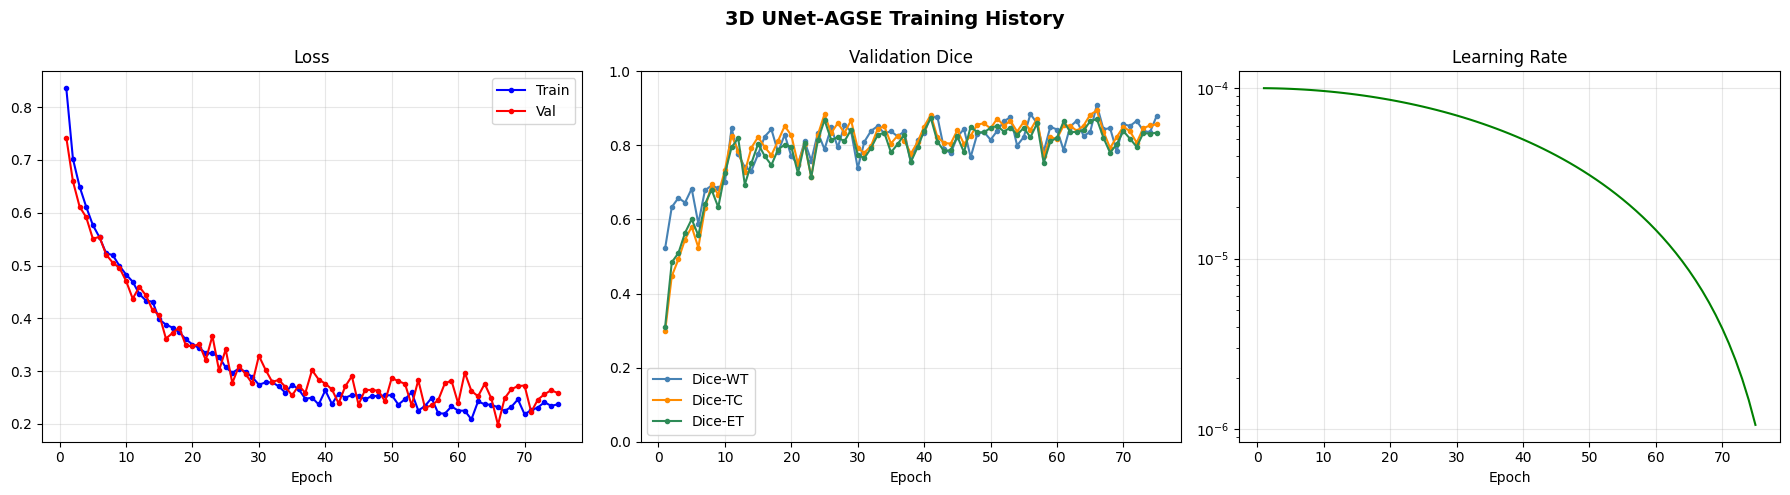

Plot saved to /content/training_history.png


In [ ]:
def plot_history(history):
    eps = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('3D UNet-AGSE Training History', fontsize=14, fontweight='bold')

    axes[0].plot(eps, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(eps, history['val_loss'],   'r-o', ms=3, label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    for region, color in [('WT','steelblue'),('TC','darkorange'),('ET','seagreen')]:
        axes[1].plot(eps, history[f'Dice_{region}'], color=color, marker='o', ms=3, label=f'Dice-{region}')
    axes[1].set_title('Validation Dice'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(eps, history['lr'], 'g-', lw=1.5)
    axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
    axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved to /content/training_history.png')


plot_history(history)

## Cell 13 — Test Set Evaluation

In [ ]:
if CKPT_BEST.exists():
    load_ckpt(CKPT_BEST, model)
    print('Best weights loaded for evaluation')


@torch.no_grad()
def eval_test(model, loader):
    model.eval()
    all_m = {'Dice_WT':[], 'Dice_TC':[], 'Dice_ET':[]}
    for imgs, masks in tqdm(loader, desc='Test'):
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        with autocast(enabled=CFG['mixed_precision'] and DEVICE.type=='cuda'):
            logits = model(imgs)
        m = brats_dice(logits, masks)
        for k in all_m: all_m[k].append(m[k])
        del imgs, masks, logits
    print('\n' + '='*40)
    print('  TEST RESULTS')
    print('='*40)
    for k, v in all_m.items():
        arr = np.array(v)
        print(f'  {k}: {arr.mean():.4f} +/- {arr.std():.4f}')
    print('='*40)
    return all_m


test_metrics = eval_test(model, test_loader)

Best weights loaded for evaluation


Test: 100%|██████████| 15/15 [01:08<00:00,  4.57s/it]


  TEST RESULTS
  Dice_WT: 0.9091 +/- 0.0506
  Dice_TC: 0.8506 +/- 0.2341
  Dice_ET: 0.7543 +/- 0.3069


## Cell 14 — Qualitative Visualisation

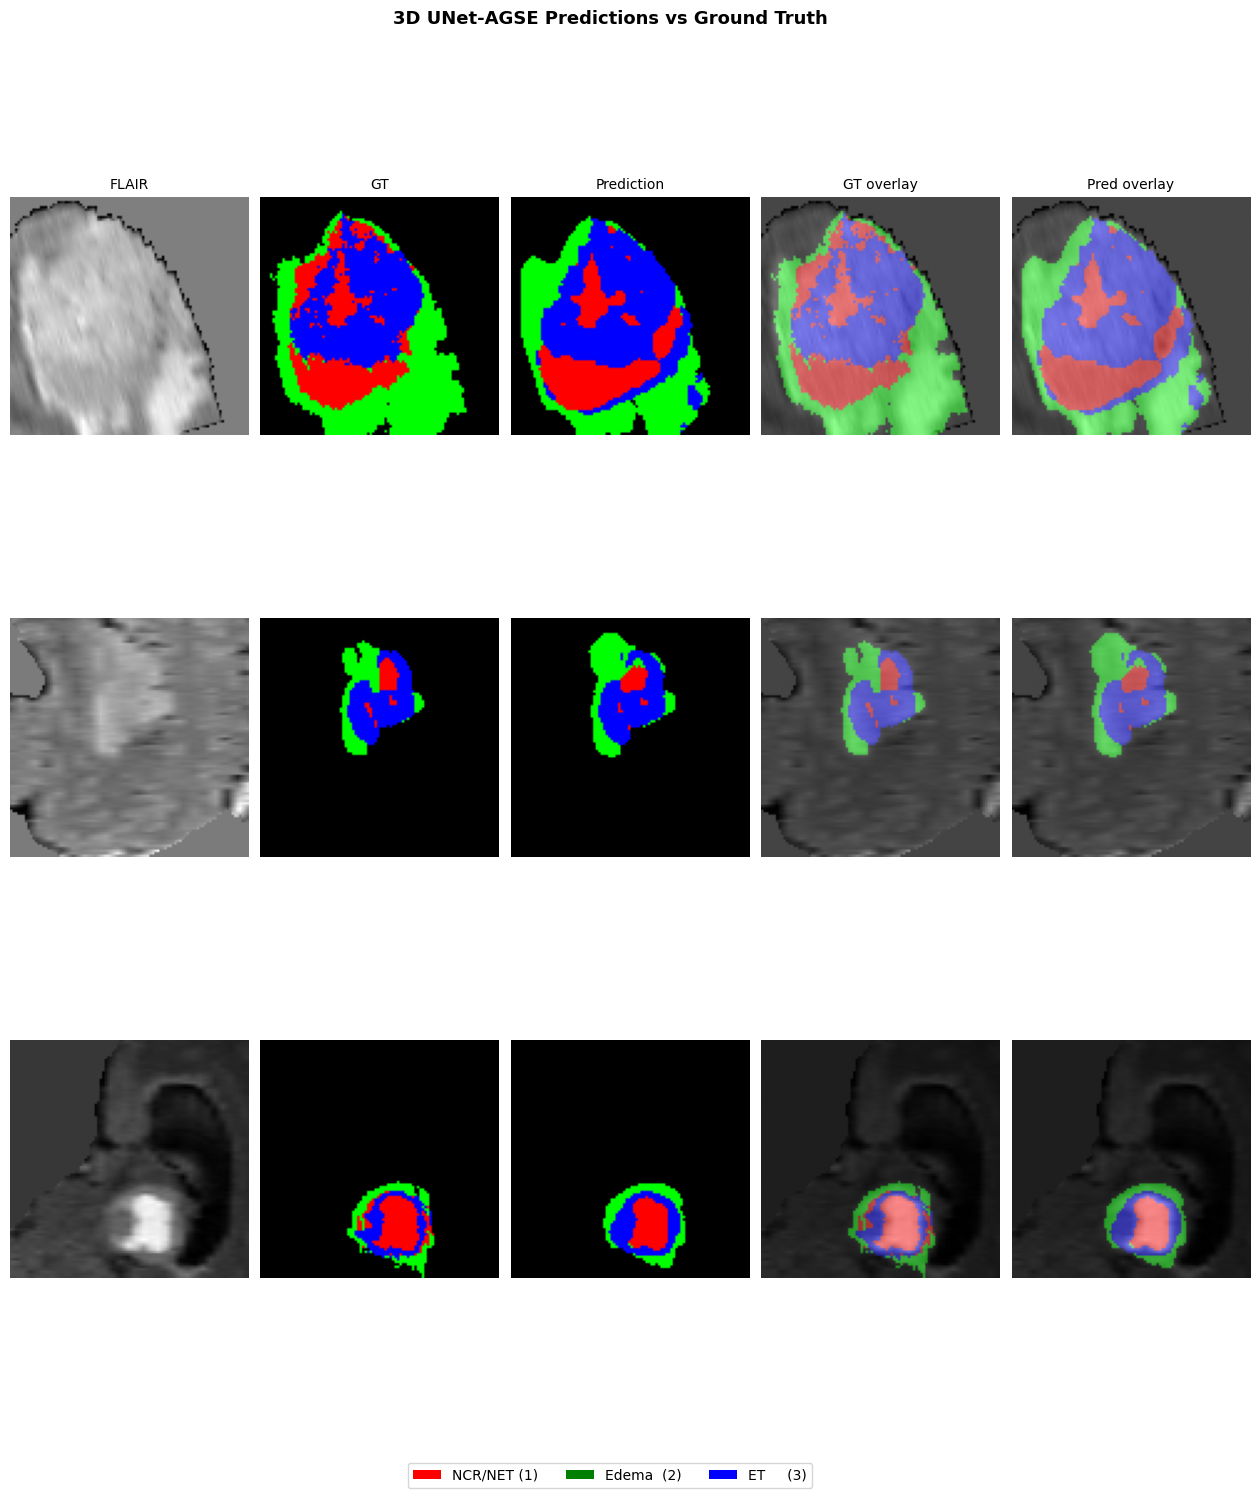

Saved to /content/predictions.png


In [ ]:
LABEL_COLORS = {
    0: [0,   0,   0  ],
    1: [255, 0,   0  ],
    2: [0,   255, 0  ],
    3: [0,   0,   255],
}

def seg_to_rgb(seg):
    rgb = np.zeros((*seg.shape, 3), dtype=np.uint8)
    for lbl, col in LABEL_COLORS.items():
        rgb[seg == lbl] = col
    return rgb


@torch.no_grad()
def visualise(model, dataset, n=3):
    model.eval()
    idxs = random.sample(range(len(dataset)), n)
    fig = plt.figure(figsize=(16, 5*n))
    fig.suptitle('3D UNet-AGSE Predictions vs Ground Truth', fontsize=13, fontweight='bold')
    gs = gridspec.GridSpec(n, 5, figure=fig, hspace=0.35, wspace=0.05)
    col_titles = ['FLAIR', 'GT', 'Prediction', 'GT overlay', 'Pred overlay']

    for row, idx in enumerate(idxs):
        img, mask = dataset[idx]
        logits = model(img.unsqueeze(0).to(DEVICE))
        pred  = logits.argmax(1).squeeze(0).cpu().numpy()
        gt    = mask.numpy()
        flair = img[0].numpy()
        z     = int((gt > 0).sum(axis=(1,2)).argmax())

        for col in range(5):
            ax = fig.add_subplot(gs[row, col])
            ax.axis('off')
            if row == 0: ax.set_title(col_titles[col], fontsize=10)
            if   col == 0: ax.imshow(flair[z], cmap='gray')
            elif col == 1: ax.imshow(seg_to_rgb(gt[z]))
            elif col == 2: ax.imshow(seg_to_rgb(pred[z]))
            elif col == 3:
                ax.imshow(flair[z], cmap='gray')
                ax.imshow(seg_to_rgb(gt[z]), alpha=0.45)
            else:
                ax.imshow(flair[z], cmap='gray')
                ax.imshow(seg_to_rgb(pred[z]), alpha=0.45)

    from matplotlib.patches import Patch
    fig.legend(handles=[
        Patch(facecolor='red',   label='NCR/NET (1)'),
        Patch(facecolor='green', label='Edema  (2)'),
        Patch(facecolor='blue',  label='ET     (3)'),
    ], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.01))
    plt.savefig('/content/predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to /content/predictions.png')


visualise(model, test_ds, n=3)

## Cell 15 — Save Results to Google Drive

In [ ]:
import shutil

SAVE_DIR = DRIVE_ROOT / 'AGSE_UNet3D_Results'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if CKPT_BEST.exists():
    shutil.copy(str(CKPT_BEST), str(SAVE_DIR / 'best_model.pth'))
    print('Best model saved to Drive')

for fname in ['training_history.png', 'predictions.png']:
    src = Path(f'/content/{fname}')
    if src.exists():
        shutil.copy(str(src), str(SAVE_DIR / fname))
        print(f'{fname} saved to Drive')

np.save(str(SAVE_DIR / 'training_history.npy'), history)

print('\n' + '='*50)
print('  FINAL SUMMARY')
print('='*50)
print(f'  Model         : 3D UNet-AGSE')
print(f'  Parameters    : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Train/Val/Test: {len(train_pts)}/{len(val_pts)}/{len(test_pts)}')
print(f'  Best Dice-WT  : {best_dice_wt:.4f}')
print(f"  Test Dice-WT  : {np.mean(test_metrics['Dice_WT']):.4f} +/- {np.std(test_metrics['Dice_WT']):.4f}")
print(f"  Test Dice-TC  : {np.mean(test_metrics['Dice_TC']):.4f} +/- {np.std(test_metrics['Dice_TC']):.4f}")
print(f"  Test Dice-ET  : {np.mean(test_metrics['Dice_ET']):.4f} +/- {np.std(test_metrics['Dice_ET']):.4f}")
print('='*50)

Best model saved to Drive
training_history.png saved to Drive
predictions.png saved to Drive

  FINAL SUMMARY
  Model         : 3D UNet-AGSE
  Parameters    : 5,987,528
  Train/Val/Test: 240/45/15
  Best Dice-WT  : 0.9094
  Test Dice-WT  : 0.9091 +/- 0.0506
  Test Dice-TC  : 0.8506 +/- 0.2341
  Test Dice-ET  : 0.7543 +/- 0.3069


## Architecture Reference

| Component | Description |
|---|---|
| 3D UNet backbone | Encoder-decoder with skip connections |
| SE Block | GlobalAvgPool to FC squeeze to ReLU to FC excite to Sigmoid to channel scale |
| Attention Gate | Additive soft-attention on skip features gated by decoder signal |
| Residual block | Double Conv-BN-ReLU + SE + identity shortcut |
| Loss | 0.6 x Dice + 0.4 x Focal (gamma=2) |
| Optimizer | Adam (lr=1e-4, wd=1e-5) |
| Scheduler | CosineAnnealing |
| Precision | FP16 mixed-precision |

### BRaTS 2021 Label Mapping
| Original | Remapped | Region |
|---|---|---|
| 0 | 0 | Background |
| 1 | 1 | Necrotic Core (NCR) |
| 2 | 2 | Peritumoral Edema (ED) |
| 4 | 3 | Enhancing Tumor (ET) |

### Sub-region Definitions
| Region | Labels |
|---|---|
| WT (Whole Tumor) | 1, 2, 3 |
| TC (Tumor Core)  | 1, 3 |
| ET (Enhancing)   | 3 |